<a href="https://colab.research.google.com/github/ibrahimshehuahmad79-droid/waec-pass-likelihood-prediction/blob/main/DS15_WAEC_Pass_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Everything is working!")

Everything is working!


In [2]:
import pandas as pd

data = pd.read_csv("student-mat.csv", sep=";")

In [3]:
data.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [4]:
data.shape

(395, 33)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [6]:
data.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [8]:
data["Pass"] = (data["G3"] >= 10).astype(int)

In [9]:
data[["G3", "Pass"]].head(10)

,G3,Pass
0,6,0
1,6,0
2,10,1
3,15,1
4,10,1
5,15,1
6,11,1
7,6,0
8,19,1
9,15,1


In [10]:
data["Pass"].value_counts()

,count
Pass,
1,265
0,130


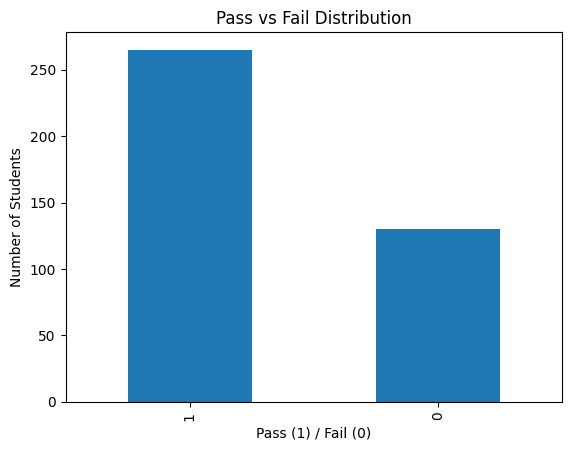

In [11]:
import matplotlib.pyplot as plt

data["Pass"].value_counts().plot(kind="bar")
plt.title("Pass vs Fail Distribution")
plt.xlabel("Pass (1) / Fail (0)")
plt.ylabel("Number of Students")
plt.show()

In [12]:
study_pass = data.groupby("studytime")["Pass"].mean()
study_pass

,Pass
studytime,
1,0.647619
2,0.646465
3,0.753846
4,0.740741


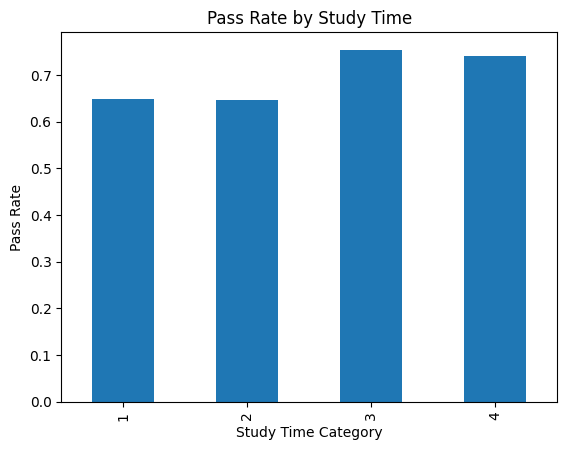

In [13]:
study_pass.plot(kind="bar")

plt.title("Pass Rate by Study Time")
plt.xlabel("Study Time Category")
plt.ylabel("Pass Rate")
plt.show()

In [14]:
failure_pass = data.groupby("failures")["Pass"].mean()
failure_pass

,Pass
failures,
0,0.750000
1,0.480000
2,0.176471
3,0.250000


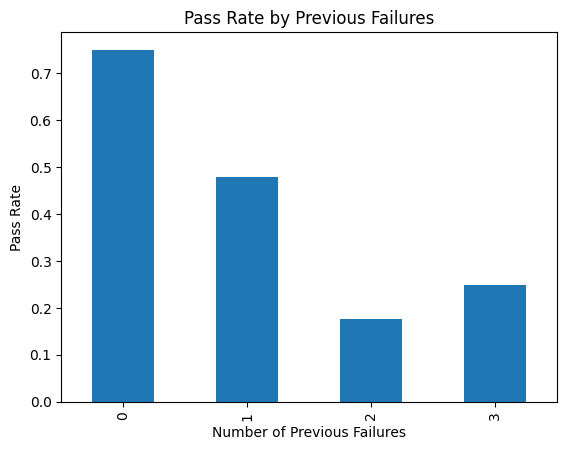

In [15]:
failure_pass.plot(kind="bar")

plt.title("Pass Rate by Previous Failures")
plt.xlabel("Number of Previous Failures")
plt.ylabel("Pass Rate")
plt.show()

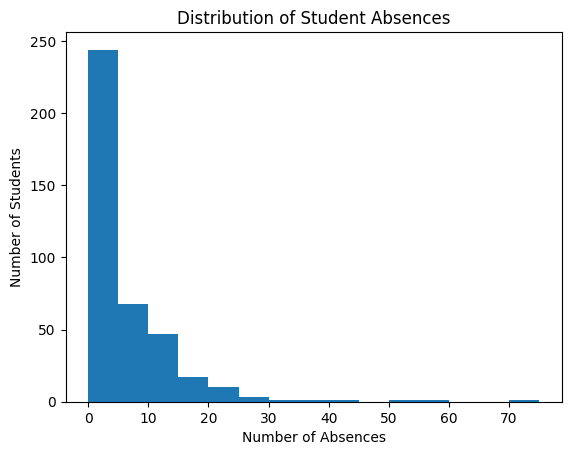

In [16]:
data["absences"].plot(kind="hist", bins=15)

plt.title("Distribution of Student Absences")
plt.xlabel("Number of Absences")
plt.ylabel("Number of Students")
plt.show()

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [20]:
data_ml = data.copy()

label_encoder = LabelEncoder()

for column in data_ml.columns:
    if data_ml[column].dtype == "object":
            data_ml[column] = label_encoder.fit_transform(data_ml[column])

In [21]:
X = data_ml.drop(["G3", "Pass"], axis=1)
y = data_ml["Pass"]

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
      X, y,
          test_size=0.2,
              random_state=42
              )


In [23]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [24]:
predictions = model.predict(X_test)

In [25]:
accuracy = accuracy_score(y_test, predictions)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.9493670886075949


In [26]:
print(confusion_matrix(y_test, predictions))

[[26  1]
 [ 3 49]]


In [27]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.90      0.96      0.93        27
           1       0.98      0.94      0.96        52

    accuracy                           0.95        79
   macro avg       0.94      0.95      0.94        79
weighted avg       0.95      0.95      0.95        79



In [29]:
predictions = model.predict(X_test)

In [30]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.9493670886075949


In [31]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)
print(cm)

[[26  1]
 [ 3 49]]


In [32]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.90      0.96      0.93        27
           1       0.98      0.94      0.96        52

    accuracy                           0.95        79
   macro avg       0.94      0.95      0.94        79
weighted avg       0.95      0.95      0.95        79



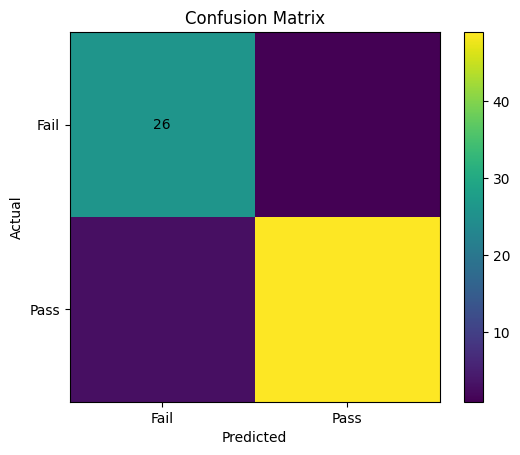

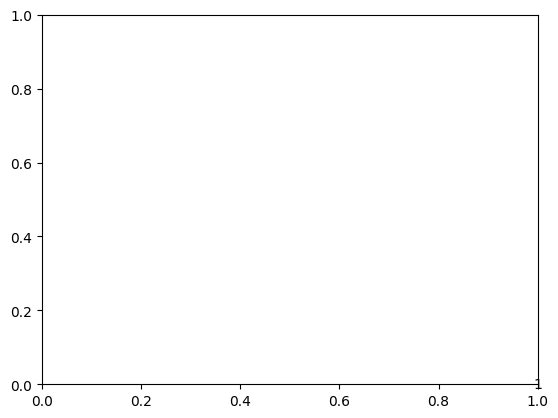

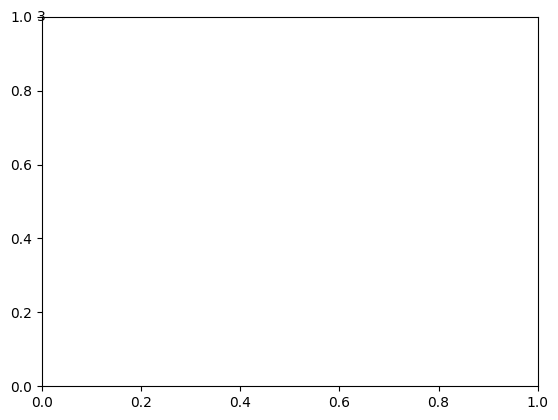

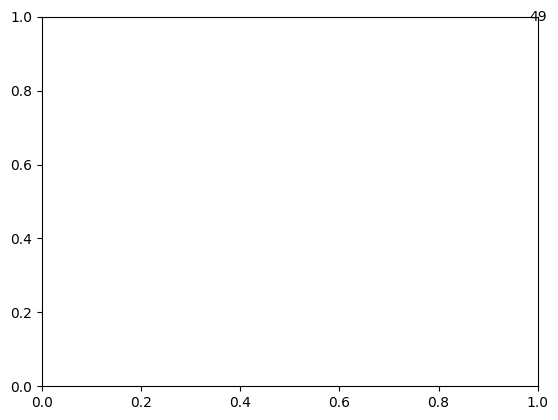

In [33]:
import matplotlib.pyplot as plt

plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks([0, 1], ["Fail", "Pass"])
plt.yticks([0, 1], ["Fail", "Pass"])

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")

            plt.show()

In [36]:


from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_predictions = dt_model.predict(X_test)

from sklearn.metrics import accuracy_score

dt_accuracy = accuracy_score(y_test, dt_predictions)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.8860759493670886


In [37]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_predictions)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9113924050632911


In [38]:
print("Logistic Regression:", accuracy)
print("Decision Tree:", dt_accuracy)
print("Random Forest:", rf_accuracy)

Logistic Regression: 0.9493670886075949
Decision Tree: 0.8860759493670886
Random Forest: 0.9113924050632911


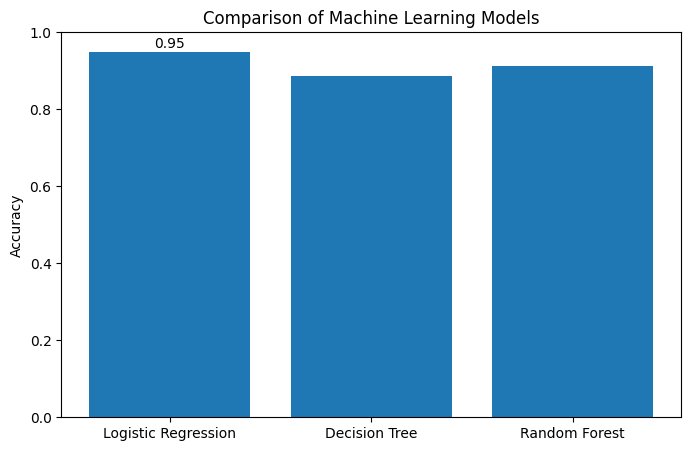

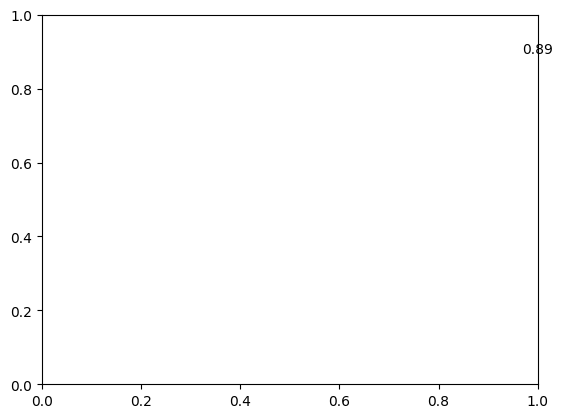

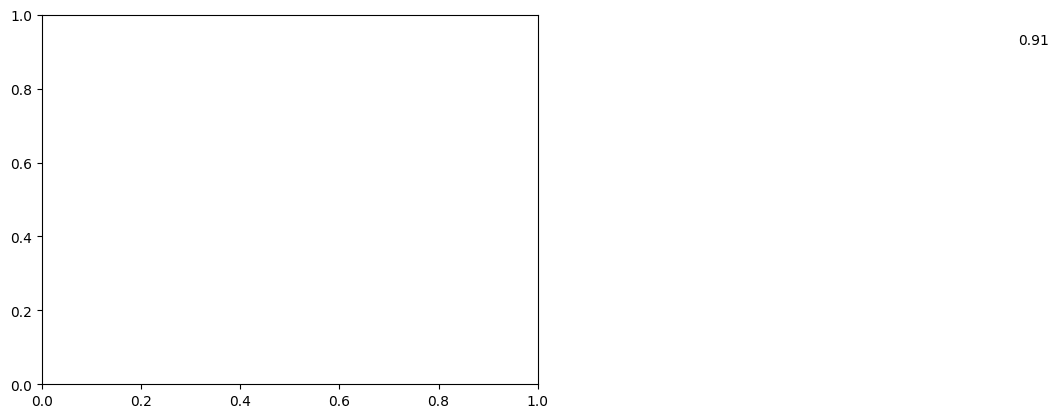

In [39]:
import matplotlib.pyplot as plt

models = ["Logistic Regression", "Decision Tree", "Random Forest"]
accuracies = [accuracy, dt_accuracy, rf_accuracy]
plt.figure(figsize=(8,5))
plt.bar(models, accuracies)
plt.title("Comparison of Machine Learning Models")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v:.2f}", ha="center")

    plt.show()

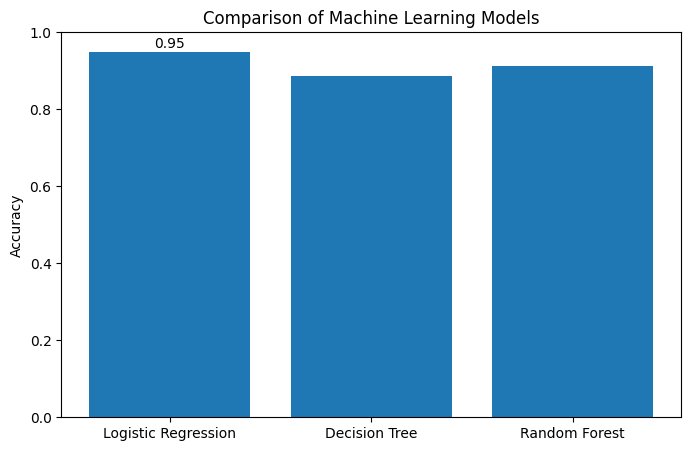

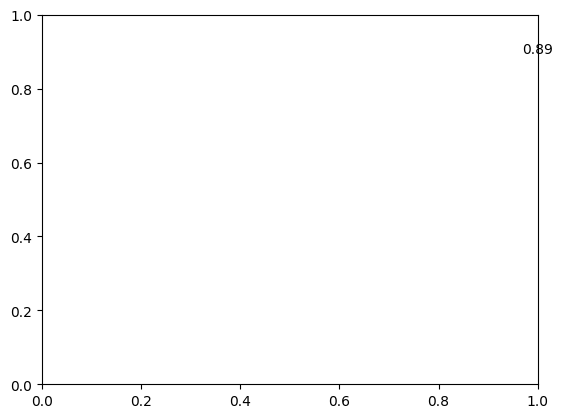

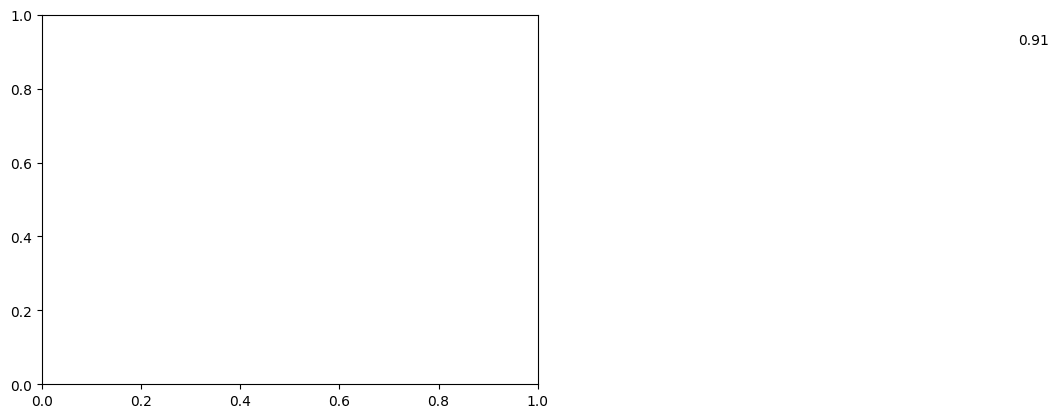

In [40]:
import matplotlib.pyplot as plt

models = ["Logistic Regression", "Decision Tree", "Random Forest"]
accuracies = [accuracy, dt_accuracy, rf_accuracy]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies)

plt.title("Comparison of Machine Learning Models")
plt.ylabel("Accuracy")
plt.ylim(0,1)

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v:.2f}", ha="center")

    plt.show()

In [41]:
print("Logistic Regression Accuracy:", accuracy)
print("Decision Tree Accuracy:", dt_accuracy)
print("Random Forest Accuracy:", rf_accuracy)

Logistic Regression Accuracy: 0.9493670886075949
Decision Tree Accuracy: 0.8860759493670886
Random Forest Accuracy: 0.9113924050632911
